# Question 4 — Otsu Thresholding and Selective Histogram Equalization
- (a) Otsu threshold for foreground mask
- (b) Equalize only the foreground region

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def show_gray(img, title=''):
    plt.figure(figsize=(6, 5))
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
    plt.show()

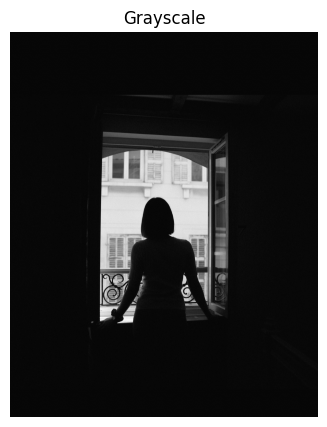

In [2]:
# Load and convert to grayscale
img = cv.imread('images/women-standing-open-door.jpg')
assert img is not None
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
show_gray(gray, 'Grayscale')

Otsu threshold value: 101


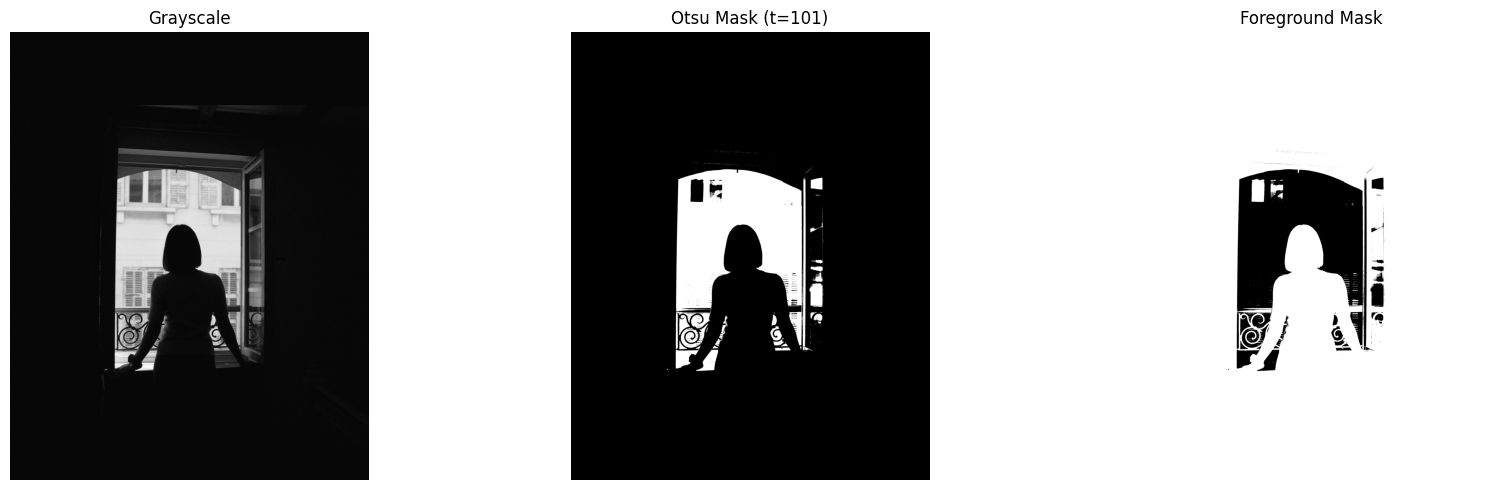

In [3]:
# (a) Otsu thresholding
# Otsu finds the threshold that minimises intra-class variance — works well
# here because the histogram is bimodal: dark room vs bright exterior window
thresh_val, mask = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
print(f'Otsu threshold value: {int(thresh_val)}')

# Invert: foreground = dark room + woman (below threshold)
fg_mask = cv.bitwise_not(mask)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(gray,    cmap='gray'); axes[0].set_title('Grayscale');              axes[0].axis('off')
axes[1].imshow(mask,    cmap='gray'); axes[1].set_title(f'Otsu Mask (t={int(thresh_val)})'); axes[1].axis('off')
axes[2].imshow(fg_mask, cmap='gray'); axes[2].set_title('Foreground Mask');        axes[2].axis('off')
plt.tight_layout()
plt.savefig('outputs/q4a_otsu.png', dpi=150, bbox_inches='tight')
plt.show()

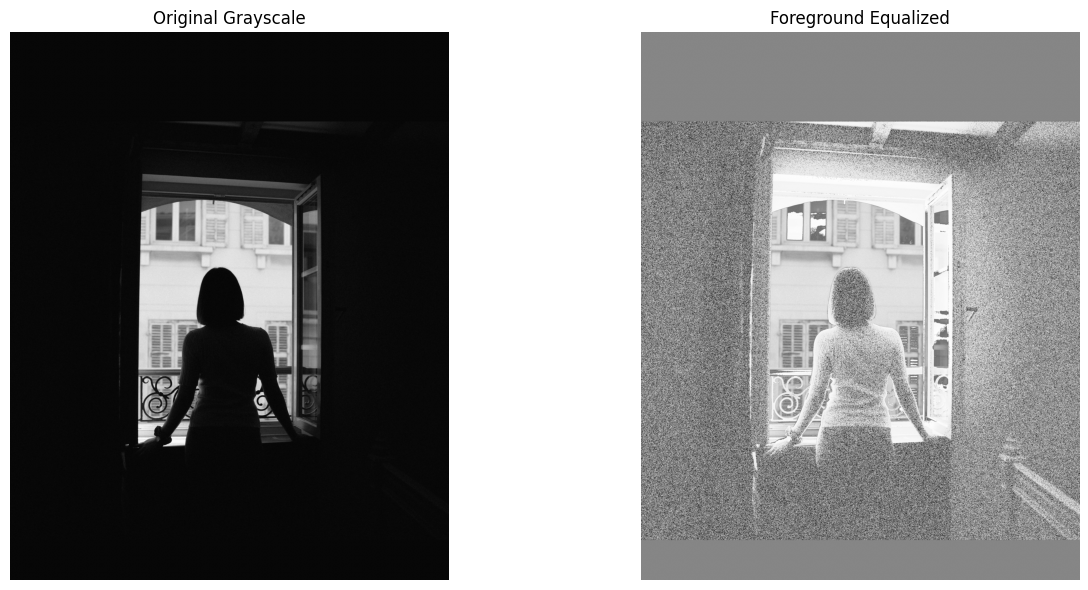

Hidden features revealed:
  - Texture and folds in the woman's clothing
  - Decorative ironwork detail on the window frame
  - Door frame edges and room wall surfaces


In [4]:
# (b) Equalize only the foreground using our custom function from Q3
def my_hist_equalization(img):
    hist = np.bincount(img.flatten(), minlength=256)
    cdf  = np.cumsum(hist / hist.sum())
    lut  = np.floor(255 * cdf).astype(np.uint8)
    return lut[img]

# Build LUT from foreground pixels only
fg_pixels = gray[fg_mask == 255]
hist  = np.bincount(fg_pixels, minlength=256)
cdf   = np.cumsum(hist / hist.sum())
lut   = np.floor(255 * cdf).astype(np.uint8)

# Apply only to foreground
result = gray.copy()
result[fg_mask == 255] = lut[gray[fg_mask == 255]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(gray,   cmap='gray', vmin=0, vmax=255); axes[0].set_title('Original Grayscale'); axes[0].axis('off')
axes[1].imshow(result, cmap='gray', vmin=0, vmax=255); axes[1].set_title('Foreground Equalized'); axes[1].axis('off')
plt.tight_layout()
plt.savefig('outputs/q4b_equalized.png', dpi=150, bbox_inches='tight')
plt.show()

print('Hidden features revealed:')
print('  - Texture and folds in the woman\'s clothing')
print('  - Decorative ironwork detail on the window frame')
print('  - Door frame edges and room wall surfaces')